Lab 4

Step 1 – Load Libraries and Dataset

In this lab, we apply data preprocessing techniques on a real estate dataset.
We start by loading the dataset and necessary libraries.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("house.csv")
df.head()

,id,location,location_area,seller_type,type,partitioning,comfort,price,rooms_count,useful_surface,built_surface,construction_year,real_estate_type,height_regime,level,max_level,kitchens_count,bathrooms_count,garages_count,parking_lots_count,balconies_count
0,101,"Bucuresti, Sector 6, zona Drumul Taberei",Drumul Taberei,agency,apartament,decomandat,lux,37400,2.0,65.0,65.0,2018.0,bloc de apartamente,S+P+6E,2,6.0,1.0,1.0,NaN,1.0,1.0
1,102,"Bucuresti, Sector 6, zona Drumul Taberei",Drumul Taberei,agency,apartament,semidecomandat,1,39900,2.0,65.0,79.0,2018.0,bloc de apartamente,P+6E,1,6.0,1.0,1.0,NaN,1.0,1.0
2,103,"Bucuresti, Sector 3, zona Dristor",Dristor,agency,apartament,decomandat,lux,90290,2.0,58.0,68.0,2020.0,bloc de apartamente,D+P+5E,4,5.0,1.0,1.0,1.0,1.0,1.0
3,104,"Bucuresti, zona Herastrau",Herastrau,agency,apartament,decomandat,lux,700000,5.0,233.0,270.0,2021.0,bloc de apartamente,D+P+5E,5,5.0,1.0,3.0,NaN,NaN,NaN
4,105,"Bucuresti, Sector 6, zona Militari",Militari,agency,apartament,decomandat,1,48000,2.0,42.0,53.0,2021.0,bloc de apartamente,D+P+10E,2,10.0,1.0,1.0,NaN,NaN,1.0


Step 2 – Data Quality Assessment (Task1)

First, we check the structure of the dataset and identify potential data quality issues such as missing values, incorrect data types, and inconsistencies.

In [11]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8320 entries, 0 to 8319
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  8320 non-null   int64  
 1   location            8320 non-null   object 
 2   location_area       8320 non-null   object 
 3   seller_type         8320 non-null   object 
 4   type                8320 non-null   object 
 5   partitioning        8146 non-null   object 
 6   comfort             8065 non-null   object 
 7   price               8320 non-null   int64  
 8   rooms_count         8319 non-null   float64
 9   useful_surface      8246 non-null   float64
 10  built_surface       7399 non-null   float64
 11  construction_year   8180 non-null   float64
 12  real_estate_type    8281 non-null   object 
 13  height_regime       8167 non-null   object 
 14  level               8319 non-null   object 
 15  max_level           8118 non-null   float64
 16  kitche

id                       0
location                 0
location_area            0
seller_type              0
type                     0
partitioning           174
comfort                255
price                    0
rooms_count              1
useful_surface          74
built_surface          921
construction_year      140
real_estate_type        39
height_regime          153
level                    1
max_level              202
kitchens_count        1163
bathrooms_count        318
garages_count         7820
parking_lots_count    6311
balconies_count       2102
dtype: int64

Step 3 – Fix Data Types

Some numerical columns are stored as text due to inconsistent entries ( "Parter" in level column).
We convert them to numeric format and coerce invalid values into NaN.

In [12]:
numeric_columns = [
    'rooms_count',
    'useful_surface',
    'built_surface',
    'construction_year',
    'level',
    'max_level',
    'kitchens_count',
    'bathrooms_count',
    'garages_count',
    'parking_lots_count',
    'balconies_count'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8320 entries, 0 to 8319
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  8320 non-null   int64  
 1   location            8320 non-null   object 
 2   location_area       8320 non-null   object 
 3   seller_type         8320 non-null   object 
 4   type                8320 non-null   object 
 5   partitioning        8146 non-null   object 
 6   comfort             8065 non-null   object 
 7   price               8320 non-null   int64  
 8   rooms_count         8319 non-null   float64
 9   useful_surface      8246 non-null   float64
 10  built_surface       7399 non-null   float64
 11  construction_year   8180 non-null   float64
 12  real_estate_type    8281 non-null   object 
 13  height_regime       8167 non-null   object 
 14  level               7235 non-null   float64
 15  max_level           8118 non-null   float64
 16  kitche

Step 4 – Handle Missing Values (Task 2)

Missing values were handled using two strategies:
Columns representing absence (garages, parking lots, balconies) were filled with 0.
Other numerical columns were filled using median imputation because housing data is often skewed.

In [14]:
df_imputed = df.copy()

zero_fill_cols = [
    'garages_count',
    'parking_lots_count',
    'balconies_count'
]

for col in zero_fill_cols:
    df_imputed[col] = df_imputed[col].fillna(0)

median_fill_cols = [
    'rooms_count',
    'useful_surface',
    'built_surface',
    'construction_year',
    'level',
    'max_level',
    'kitchens_count',
    'bathrooms_count'
]

for col in median_fill_cols:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())

df_imputed.isna().sum()

id                      0
location                0
location_area           0
seller_type             0
type                    0
partitioning          174
comfort               255
price                   0
rooms_count             0
useful_surface          0
built_surface           0
construction_year       0
real_estate_type       39
height_regime         153
level                   0
max_level               0
kitchens_count          0
bathrooms_count         0
garages_count           0
parking_lots_count      0
balconies_count         0
dtype: int64

Step 5 – Detect and Handle Outliers (Task 3)

We detect outliers in the price column using the Interquartile Range (IQR) method.
Values outside the acceptable range are considered extreme and removed.

Visualize Outliers

Visualize Outliers

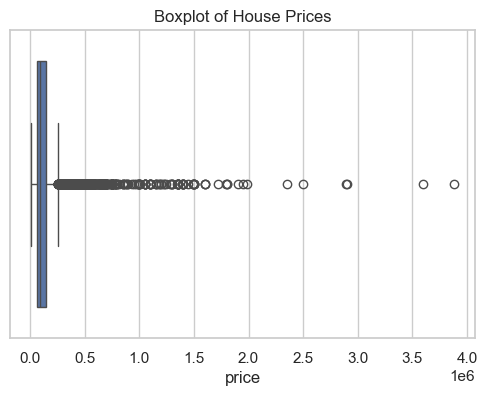

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_imputed['price'])
plt.title("Boxplot of House Prices")
plt.show()

Apply IQR Method

In [17]:
Q1 = df_imputed['price'].quantile(0.25)
Q3 = df_imputed['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_no_outliers = df_imputed[
    (df_imputed['price'] >= lower) &
    (df_imputed['price'] <= upper)
]

print("Original Shape:", df_imputed.shape)
print("After Removing Outliers:", df_no_outliers.shape)

Original Shape: (8320, 21)
After Removing Outliers: (7534, 21)


Step 6 – Normalization (Task 4)

In [18]:
features = [
    'price',
    'rooms_count',
    'useful_surface',
    'bathrooms_count'
]

Min-Max normalization rescales features between 0 and 1

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_minmax = scaler.fit_transform(df_no_outliers[features])
df_minmax[:5]

array([[0.11075182, 0.14285714, 0.17630058, 0.        ],
       [0.12085691, 0.14285714, 0.17630058, 0.        ],
       [0.32453517, 0.14285714, 0.15606936, 0.        ],
       [0.15359741, 0.14285714, 0.10982659, 0.        ],
       [0.50525465, 0.14285714, 0.13294798, 0.        ]])

Z-score standardization transforms features so that mean = 0 and standard deviation = 1.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = scaler.fit_transform(df_no_outliers[features])
df_standardized[:5]

array([[-1.23652094, -0.48546138, -0.05225851, -0.65850988],
       [-1.18538006, -0.48546138, -0.05225851, -0.65850988],
       [-0.15458439, -0.48546138, -0.34356064, -0.65850988],
       [-1.01968359, -0.48546138, -1.00939406, -0.65850988],
       [ 0.76001918, -0.48546138, -0.67647735, -0.65850988]])

Step 7 – PCA (Task 5)

Principal Component Analysis (PCA) reduces dimensionality by transforming correlated features into new uncorrelated components that capture maximum variance.

Apply PCA

Apply PCA

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_components = pca.fit_transform(df_standardized)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.73787747 0.11894473]


Visualize PCA

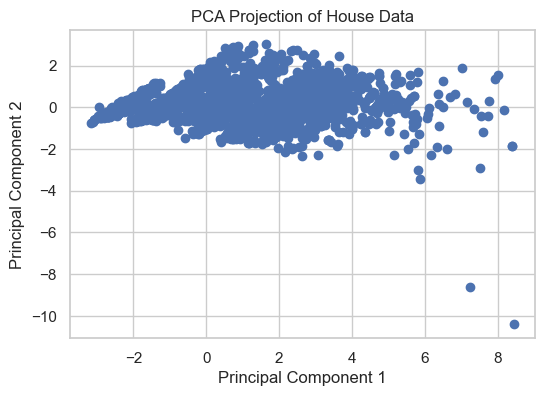

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of House Data")
plt.show()